<a href="https://colab.research.google.com/github/VasilinaFrolova/MyPain/blob/main/%D0%A4%D1%80%D0%BE%D0%BB%D0%BE%D0%B2%D0%B0_%D0%92%D0%B0%D1%81%D0%B8%D0%BB%D0%B8%D0%BD%D0%B0_%22RNN_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **RNN/LSTM**

Цель семинара: получить практический опыт работы с RNN (LSTM) в PyTorch на задачах генерации последовательностей

Мы разберем полный пайплайн разработки от препроцессинга данных до обучения и экспериментов с гиперпараметрами

Кстати, что мы называем **пайплайном**?

В Google Colab (рекомендуется активировать GPU: `Среда выполнения → Сменить среду выполнения → T4 GPU`)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

## **ЧАСТЬ 1: ДЕМО**
*   **Задача модели:** предсказание случайного временного ряда (синусоида)
*   **Цель демонстрации:** показать полный и минимальный рабочий пайплайн RNN на задаче, связанной с обработкой данных, передающих изменения во времени
*   **План:**
    1.  Подготовка последовательностей (sequences)
    2.  Архитектура `nn.LSTM`
    3.  Обучение модели
    4.  Получение метрик оценки
    5.  Визуализация и интерпретация результата

### 1. ГЕНЕРАЦИЯ И ПОДГОТОВКА ДАННЫХ

In [2]:
def generate_sine_wave(seq_length=1000, periods=5):
    """Генерация синусоиды."""
    x = np.linspace(0, periods * 2 * np.pi, seq_length)
    y = np.sin(x)
    return y

# Генерация данных
data = generate_sine_wave()
print(f"Длина временного ряда: {len(data)}")

Длина временного ряда: 1000


In [3]:
# Параметры последовательностей
SEQ_LEN = 50  # Длина входной последовательности для предсказания
BATCH_SIZE = 16

In [4]:
def create_sequences(data, seq_len):
    """Создание пар (входная последовательность, целевое значение)."""
    sequences = []
    targets = []
    for i in range(len(data) - seq_len - 1):
        seq = data[i:i + seq_len]
        target = data[i + seq_len]
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

In [5]:
# Создание последовательностей
X, y = create_sequences(data, SEQ_LEN)
print(f"Форма X (последовательности): {X.shape}")
print(f"Форма y (цели): {y.shape}")

Форма X (последовательности): (949, 50)
Форма y (цели): (949,)


In [6]:
# Преобразование в тензоры PyTorch и добавление размерности для признаков
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # [примеры, SEQ_LEN, 1]
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # [примеры, 1]
print(f"Форма X (тензор): {X.shape}")
print(f"Форма y (тензор): {y.shape}")

Форма X (тензор): torch.Size([949, 50, 1])
Форма y (тензор): torch.Size([949, 1])


In [7]:
# Разделение на обучающую и тестовую выборки
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [8]:
### 2. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM
class SineLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True  # формат [batch, seq_len, features]
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Инициализация скрытого состояния и состояния ячейки
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # Прямой проход через LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Берем только последний выход последовательности для предсказания
        out = self.fc(out[:, -1, :])
        return out

In [9]:
# Инициализация модели
model = SineLSTM()
print(f"Модель:\n{model}")

Модель:
SineLSTM(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


### 3. ОБУЧЕНИЕ МОДЕЛИ

In [10]:
# Гиперпараметры
EPOCHS = 20
LEARNING_RATE = 0.01

# Функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Тренировочный цикл
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    model.train()

    # Прямой проход
    predictions = model(X_train)
    loss = criterion(predictions, y_train)

    # Обратное распространение
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Оценка на тестовой выборке
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test)
        test_loss = criterion(test_predictions, y_test)
        test_losses.append(test_loss.item())

    if (epoch + 1) % 5 == 0:
        print(f'Эпоха [{epoch+1}/{EPOCHS}], '
              f'Ошибка обучения: {loss.item():.6f}, '
              f'Ошибка теста: {test_loss.item():.6f}')

Эпоха [5/20], Ошибка обучения: 0.249852, Ошибка теста: 0.230390
Эпоха [10/20], Ошибка обучения: 0.096505, Ошибка теста: 0.097033
Эпоха [15/20], Ошибка обучения: 0.029065, Ошибка теста: 0.030359
Эпоха [20/20], Ошибка обучения: 0.027864, Ошибка теста: 0.018298


### 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

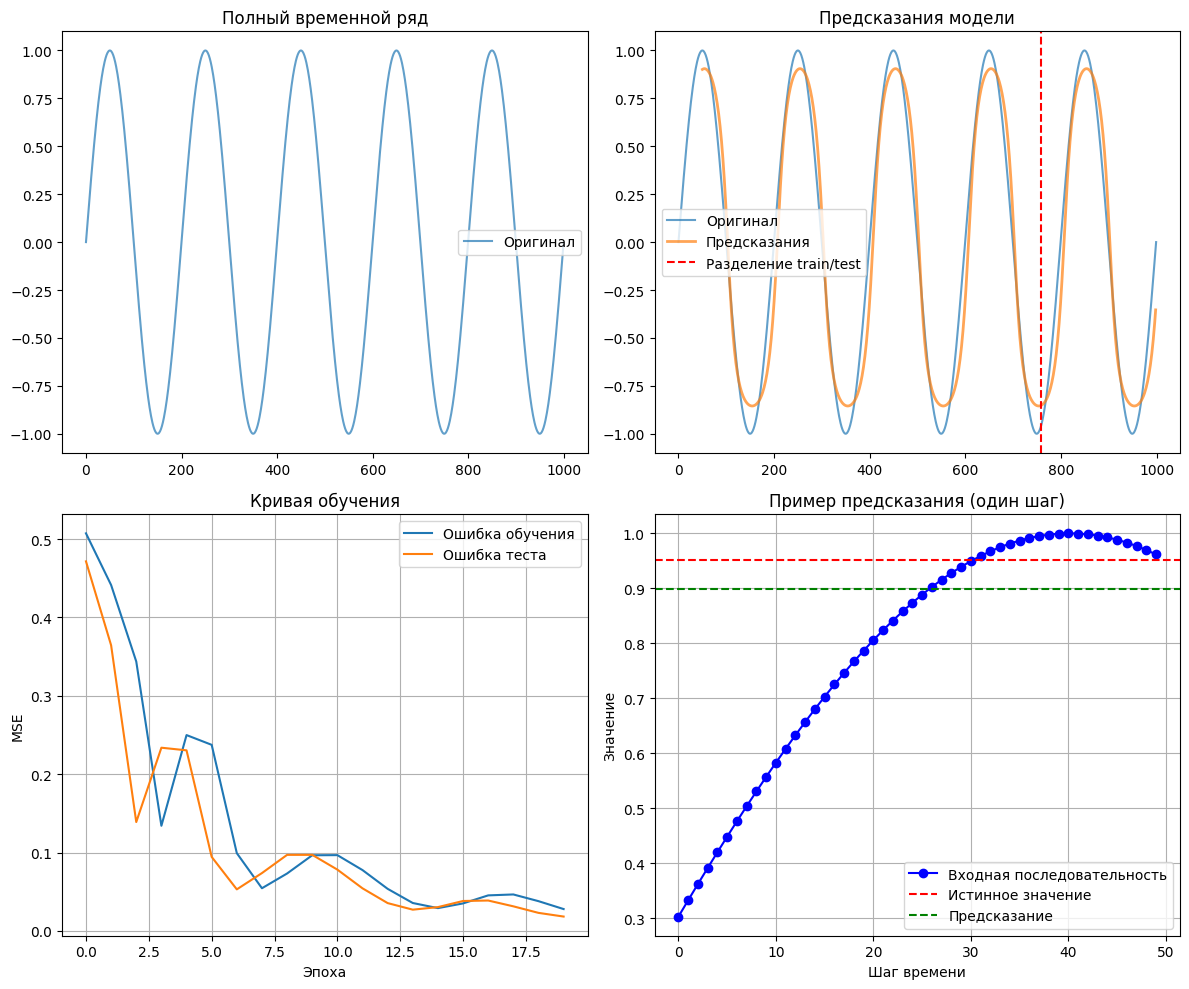

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# График 1: Оригинальные данные и предсказания
axes[0, 0].plot(data, label='Оригинал', alpha=0.7)
axes[0, 0].set_title('Полный временной ряд')
axes[0, 0].legend()

# График 2: Предсказания на тестовой выборке
model.eval()
with torch.no_grad():
    all_predictions = model(X).numpy()

# Создание массива для отображения предсказаний
pred_series = np.full_like(data, np.nan)
pred_series[SEQ_LEN:SEQ_LEN + len(all_predictions)] = all_predictions.squeeze()

axes[0, 1].plot(data, label='Оригинал', alpha=0.7)
axes[0, 1].plot(pred_series, label='Предсказания', alpha=0.7, linewidth=2)
axes[0, 1].axvline(x=split_idx, color='r', linestyle='--', label='Разделение train/test')
axes[0, 1].set_title('Предсказания модели')
axes[0, 1].legend()

# График 3: Ошибки обучения и теста
axes[1, 0].plot(train_losses, label='Ошибка обучения')
axes[1, 0].plot(test_losses, label='Ошибка теста')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].set_title('Кривая обучения')
axes[1, 0].legend()
axes[1, 0].grid(True)

# График 4: Пример одного предсказания
sample_idx = split_idx + 50
axes[1, 1].plot(range(SEQ_LEN), X[sample_idx].squeeze().numpy(),
                'bo-', label='Входная последовательность')
axes[1, 1].axhline(y=y[sample_idx].item(), color='r', linestyle='--',
                   label='Истинное значение')
axes[1, 1].axhline(y=all_predictions[sample_idx].item(), color='g',
                   linestyle='--', label='Предсказание')
axes[1, 1].set_xlabel('Шаг времени')
axes[1, 1].set_ylabel('Значение')
axes[1, 1].set_title('Пример предсказания (один шаг)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### 5. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
1. Кривая обучения должна снижаться на обеих выборках
2. Предсказания должны следовать за оригинальным рядом
3. Разрыв между train/test loss указывает на переобучение
4. Модель учится предсказывать следующий шаг синусоиды

Take aways:

1. Подготовка последовательностей: как из временного ряда создаются пары (окно истории -> целевое значение)?

2. Архитектура LSTM: batch_first=True, почему берем out[:, -1, :]

3. Цикл обучения: разделение на model.train() и model.eval(), логика .zero_grad(), .backward(), .step()

4. Визуализация: как интерпретировать каждый из 4-х графиков?

---

# ПРАКТИКА

1. ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНЫЙ ПРОСМОТР ДАННЫХ

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

https://www.tensorflow.org/api_docs/python/tf/keras/datasets/reuters/load_data

In [13]:
# TODO 1.1: Загрузите датасет Reuters
(x_train, y_train), (x_test, y_test) = reuters.load_data()

# TODO 1.2: Изучите структуру данных
print("Тип x_train:", type(x_train))
print("Длина x_train:", len(x_train))
print("Первая последовательность (первые 10 индексов):", x_train[0][:10])
print("Длина первой последовательности:", len(x_train[0]))

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Тип x_train: <class 'numpy.ndarray'>
Длина x_train: 8982
Первая последовательность (первые 10 индексов): [1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207]
Длина первой последовательности: 87


2. ПОДГОТОВКА СЛОВАРЯ И ДЕКОДИРОВАНИЕ

In [14]:
# TODO 2.1: Загрузите словарь слов
word_index = reuters.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
# TODO 2.2: Реализуйте функцию декодирования последовательности
def decode_sequence(sequence):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in sequence])

first_article = decode_sequence(x_train[0])
print("\nПервая статья (первые 200 символов):", first_article[:200])


Первая статья (первые 200 символов): ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net shou


3. ПОДГОТОВКА ДАННЫХ ДЛЯ ГЕНЕРАЦИИ ТЕКСТА

In [16]:
# TODO 3.1: Объедините первые 1000 статей в один текст
max_articles = 1000
max_articles_idx = x_train[:max_articles]
max_articles_texts = [decode_sequence(seq) for seq in max_articles_idx]
texts = ' '.join(max_articles_texts)

print(f"Общая длина текста (символов): {len(texts)}")
print("Пример текста:", texts[:500])

Общая длина текста (символов): 815340
Пример текста: ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3 ? generale de banque sa lt genb br and lt heller overseas corp of chicago have each taken 50 pct 


In [17]:
# TODO 3.2: Создайте словари для преобразования символов в индексы и обратно
chars = sorted(list(set(texts)))
print(chars)

[' ', "'", '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [18]:
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)
print(f"Размер словаря (уникальных символов): {vocab_size}")

Размер словаря (уникальных символов): 39


In [19]:
idx_to_char

{0: ' ',
 1: "'",
 2: '0',
 3: '1',
 4: '2',
 5: '3',
 6: '4',
 7: '5',
 8: '6',
 9: '7',
 10: '8',
 11: '9',
 12: '?',
 13: 'a',
 14: 'b',
 15: 'c',
 16: 'd',
 17: 'e',
 18: 'f',
 19: 'g',
 20: 'h',
 21: 'i',
 22: 'j',
 23: 'k',
 24: 'l',
 25: 'm',
 26: 'n',
 27: 'o',
 28: 'p',
 29: 'q',
 30: 'r',
 31: 's',
 32: 't',
 33: 'u',
 34: 'v',
 35: 'w',
 36: 'x',
 37: 'y',
 38: 'z'}

In [20]:
# TODO 3.3: Преобразуйте текст в последовательность индексов
text_as_int = [char_to_idx[ch] for ch in texts]
texts[:10], text_as_int[:10]

('? mcgrath ', [12, 0, 25, 15, 19, 30, 13, 32, 20, 0])

In [21]:
text_as_int = np.array(text_as_int)

text_as_int

array([12,  0, 25, ..., 30,  0,  5])

4. ФОРМИРОВАНИЕ ПРОМПТОВ И ОТВЕТОВ

In [22]:
seq_length = 100

In [23]:
# TODO 4.1: Реализуйте функцию create_sequences для создания обучающих примеров
def create_sequences(text_indices, seq_len):
    input_seq = []
    target_seq = []

    for i in range(len(text_indices)-seq_len):
        current_x_seq = text_indices[i:i+seq_len]
        input_seq.append(current_x_seq)

        current_y_seq = text_indices[i+seq_len]
        target_seq.append(current_y_seq)

    return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)

input_seq, target_seq = create_sequences(text_as_int, seq_length)

/tmp/ipython-input-889/2203781802.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)


In [24]:
input_seq

tensor([[12,  0, 25,  ..., 17, 30,  0],
        [ 0, 25, 15,  ..., 30,  0, 31],
        [25, 15, 19,  ...,  0, 31, 20],
        ...,
        [26, 21, 26,  ..., 33, 32, 17],
        [21, 26, 17,  ..., 32, 17, 30],
        [26, 17,  0,  ..., 17, 30,  0]])

In [25]:
target_seq

tensor([31, 20, 13,  ..., 30,  0,  5])

In [26]:
print(f"Количество примеров: {len(input_seq)}")
print(f"Форма input_seq: {input_seq.shape}")
print(f"Форма target_seq: {target_seq.shape}")

Количество примеров: 815240
Форма input_seq: torch.Size([815240, 100])
Форма target_seq: torch.Size([815240])


In [27]:
# TODO 4.2: Создайте DataLoader для пакетной обработки
batch_size = 32
dataset = torch.utils.data.TensorDataset(input_seq, target_seq)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [28]:
dataset

In [29]:
dataloader

5. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM

In [30]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, embedding_dim=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # TODO 5.1: Определите слои модели
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2,
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # TODO 5.2: Реализуйте forward pass
        # Шаг 1: Примените слой эмбеддинга
        embedded = self.embedding(x)

        # Шаг 2: Прямой проход через LSTM
        if hidden is None:
            lstm_out, hidden = self.lstm(embedded)
        else:
            lstm_out, hidden = self.lstm(embedded, hidden)

        # Шаг 3: Возьмите только последний выход LSTM
        lstm_out = lstm_out[:, -1, :]

        # Шаг 4: Примените полносвязный слой
        output = self.fc(lstm_out)

        return output, hidden

device = torch.device('cuda')

# TODO 5.3: Инициализируйте модель
model = CharLSTM(vocab_size=vocab_size, hidden_size=128, num_layers=2)
model = model.to(device)
print(f"\nМодель:\n{model}")


Модель:
CharLSTM(
  (embedding): Embedding(39, 64)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=39, bias=True)
)


6. ОБУЧЕНИЕ МОДЕЛИ

In [31]:
EPOCHS = 4
LEARNING_RATE = 0.005

In [32]:
# TODO 6.1: Определите функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [33]:
# Функция для генерации текста
def generate_text(model, seed_text, length=100, temperature=1.0):
    """Генерация текста на основе начальной последовательности."""
    model.eval()
    generated = seed_text

    # Преобразуем seed в индексы, фильтруя символы, которых нет в словаре
    seed_indices = []
    for ch in seed_text:
        if ch in char_to_idx:
            seed_indices.append(char_to_idx[ch])
        else:
            # Если символа нет в словаре, используем первый попавшийся символ
            seed_indices.append(0)

    if len(seed_indices) == 0:
        seed_indices = [0]  # На случай пустого seed

    with torch.no_grad():
        # Создаем начальное hidden state
        batch_size = 1
        h0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        c0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        hidden = (h0, c0)

        # "Прогреваем" модель на seed последовательности
        for i in range(len(seed_indices) - 1):
            input_tensor = torch.tensor([[seed_indices[i]]], dtype=torch.long).to(device)
            _, hidden = model(input_tensor, hidden)

        # Начинаем генерацию
        current_input = torch.tensor([[seed_indices[-1]]], dtype=torch.long).to(device)

        for _ in range(length):
            output, hidden = model(current_input, hidden)

            # Применяем temperature для управления случайностью
            output = output / temperature
            probabilities = torch.softmax(output, dim=-1)

            # Выбираем следующий символ на основе вероятностей
            next_char_idx = torch.multinomial(probabilities, 1).item()

            # Добавляем символ к сгенерированному тексту
            generated += idx_to_char[next_char_idx]

            # Обновляем вход для следующей итерации
            current_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)

    return generated

# Тренировочный цикл
train_losses = []

print("\nНачало обучения...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    batch_count = len(dataloader)

    for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
        # Перемещаем данные на GPU
        batch_input = batch_input.to(device)
        batch_target = batch_target.to(device)

        optimizer.zero_grad()

        # Прямой проход
        output, _ = model(batch_input)
        loss = criterion(output, batch_target)

        # Обратное распространение
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        # Логгирование прогресса каждые 50 батчей
        if (batch_idx + 1) % 50 == 0:
            avg_batch_loss = loss.item()
            print(f'Эпоха [{epoch+1}/{EPOCHS}], Батч [{batch_idx+1}/{batch_count}], Потеря: {avg_batch_loss:.4f}')

    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)

    # Генерация текста для мониторинга прогресса
    if (epoch + 1) % 2 == 0:
        # Используем seed текст, который точно есть в нашем словаре
        # Преобразуем к нижнему регистру, чтобы гарантировать наличие символов
        seed = "the company said"
        # Альтернативно: можно проверить, какие символы есть в словаре
        safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
        if len(safe_seed) > 0:
            generated = generate_text(model, safe_seed, length=50, temperature=0.8)
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print(f'Сгенерированный текст: "{generated}"')
        else:
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print('Не удалось сгенерировать текст: seed содержит неизвестные символы')


Начало обучения...
Эпоха [1/4], Батч [50/25477], Потеря: 2.9275
Эпоха [1/4], Батч [100/25477], Потеря: 2.6883
Эпоха [1/4], Батч [150/25477], Потеря: 2.4092
Эпоха [1/4], Батч [200/25477], Потеря: 2.3728
Эпоха [1/4], Батч [250/25477], Потеря: 2.5813
Эпоха [1/4], Батч [300/25477], Потеря: 1.9425
Эпоха [1/4], Батч [350/25477], Потеря: 2.0936
Эпоха [1/4], Батч [400/25477], Потеря: 2.2968
Эпоха [1/4], Батч [450/25477], Потеря: 2.1779
Эпоха [1/4], Батч [500/25477], Потеря: 1.8494
Эпоха [1/4], Батч [550/25477], Потеря: 2.1085
Эпоха [1/4], Батч [600/25477], Потеря: 2.2214
Эпоха [1/4], Батч [650/25477], Потеря: 2.2112
Эпоха [1/4], Батч [700/25477], Потеря: 2.5949
Эпоха [1/4], Батч [750/25477], Потеря: 1.6870
Эпоха [1/4], Батч [800/25477], Потеря: 2.0294
Эпоха [1/4], Батч [850/25477], Потеря: 1.7415
Эпоха [1/4], Батч [900/25477], Потеря: 2.1013
Эпоха [1/4], Батч [950/25477], Потеря: 1.9718
Эпоха [1/4], Батч [1000/25477], Потеря: 2.0709
Эпоха [1/4], Батч [1050/25477], Потеря: 2.1288
Эпоха [1/4], 

---

# ДОМАШНЕЕ ЗАДАНИЕ (дедлайн: 28 февраля, 23.59)

**Задача:** обучить модель с разными гиперпараметрами

1. Набор A: hidden_size=64, num_layers=1, learning_rate=0.01

2. Набор B: hidden_size=256, num_layers=2, learning_rate=0.001

3. Набор C: любой произвольный набор параметров hidden_size, num_layers, learning_rate, отличный от предложенных

Сравните:

- Скорость сходимости (график loss)
- Качество генерации (осмысленность текста)
- Время обучения

### **ВОПРОСЫ ДЛЯ РЕФЛЕКСИИ**

1.  Какие ключевые отличия вы заметили в подготовке данных для числового ряда (синусоида) и текста?

2.  Какой опыт работы с PyTorch (например, отладка, подбор параметров) оказался самым полезным?

Using device: cuda
Общая длина текста (символов): 815340
Размер словаря: 39

--- Обучение с параметрами: hidden_size=64, num_layers=1, lr=0.01 ---
Эпоха 1/4, Loss: 1.8156
Эпоха 2/4, Loss: 1.7713
Эпоха 3/4, Loss: 1.7997
Эпоха 4/4, Loss: 1.8300
Время обучения: 377.42 сек
Сгенерированный текст: the company said indartion the seakled wirueme the said been part in chas of dining mey thack commiriry twhared farm

--- Обучение с параметрами: hidden_size=256, num_layers=2, lr=0.001 ---
Эпоха 1/4, Loss: 1.4500
Эпоха 2/4, Loss: 1.2444
Эпоха 3/4, Loss: 1.2064
Эпоха 4/4, Loss: 1.1914
Время обучения: 1209.39 сек
Сгенерированный текст: the company said it has been some of the firm of 15 mln dlrs shares with the end of 4 3 pct or 15 17 pct of the atte

--- Обучение с параметрами: hidden_size=128, num_layers=3, lr=0.005 ---
Эпоха 1/4, Loss: 1.6970
Эпоха 2/4, Loss: 1.5063
Эпоха 3/4, Loss: 1.4663
Эпоха 4/4, Loss: 1.4470
Время обучения: 580.64 сек
Сгенерированный текст: the company said the supply reuter

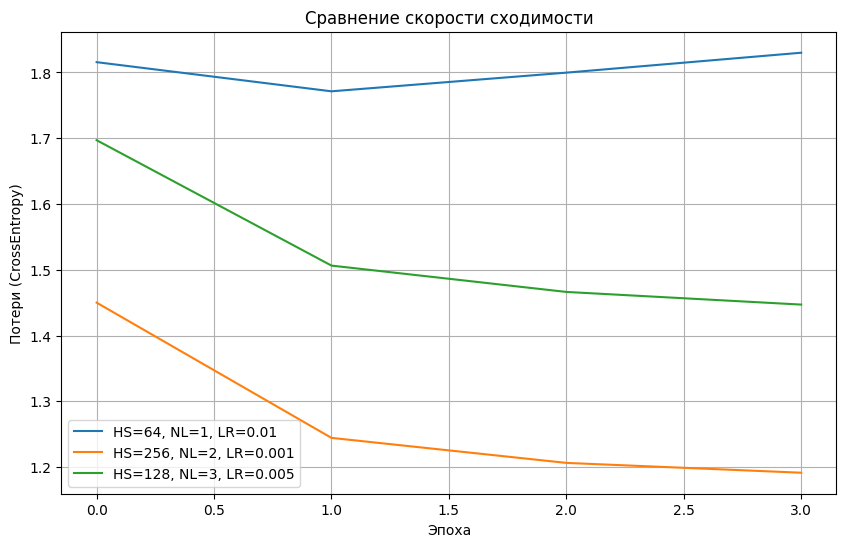


Сводная таблица результатов
HS= 64, NL=1, LR=0.010 | Финальная потеря: 1.8300 | Время: 377.42 сек | Генерация: the company said indartion the seakled wirueme the...
HS=256, NL=2, LR=0.001 | Финальная потеря: 1.1914 | Время: 1209.39 сек | Генерация: the company said it has been some of the firm of 1...
HS=128, NL=3, LR=0.005 | Финальная потеря: 1.4470 | Время: 580.64 сек | Генерация: the company said the supply reuter 3 ? the more ha...


In [34]:
# Импорт библиотек
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.datasets import reuters

# Проверка GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
(x_train, y_train), (x_test, y_test) = reuters.load_data()
word_index = reuters.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

def decode_sequence(sequence):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in sequence])

# Используем первые max_articles статей
max_articles = 1000  # можно уменьшить для скорости
max_articles_idx = x_train[:max_articles]
max_articles_texts = [decode_sequence(seq) for seq in max_articles_idx]
texts = ' '.join(max_articles_texts)
print(f"Общая длина текста (символов): {len(texts)}")

# Словарь символов
chars = sorted(list(set(texts)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}
vocab_size = len(chars)
print(f"Размер словаря: {vocab_size}")

# Преобразование текста в индексы
text_as_int = [char_to_idx[ch] for ch in texts]
text_as_int = np.array(text_as_int)

# Создание последовательностей
seq_length = 100
def create_sequences(text_indices, seq_len):
    input_seq = []
    target_seq = []
    for i in range(len(text_indices)-seq_len):
        input_seq.append(text_indices[i:i+seq_len])
        target_seq.append(text_indices[i+seq_len])
    return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)

input_seq, target_seq = create_sequences(text_as_int, seq_length)

# DataLoader
batch_size = 32
dataset = torch.utils.data.TensorDataset(input_seq, target_seq)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

# 2. ОПРЕДЕЛЕНИЕ МОДЕЛИ (но с параметрами)
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, embedding_dim=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0  # dropout только если больше 1 слоя
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        if hidden is None:
            lstm_out, hidden = self.lstm(embedded)
        else:
            lstm_out, hidden = self.lstm(embedded, hidden)
        lstm_out = lstm_out[:, -1, :]
        output = self.fc(lstm_out)
        return output, hidden

# Функция генерации текста
def generate_text(model, seed_text, length=100, temperature=1.0):
    model.eval()
    generated = seed_text
    seed_indices = []
    for ch in seed_text:
        if ch in char_to_idx:
            seed_indices.append(char_to_idx[ch])
        else:
            seed_indices.append(0)
    if len(seed_indices) == 0:
        seed_indices = [0]
    with torch.no_grad():
        batch_size = 1
        h0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        c0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        hidden = (h0, c0)
        for i in range(len(seed_indices) - 1):
            input_tensor = torch.tensor([[seed_indices[i]]], dtype=torch.long).to(device)
            _, hidden = model(input_tensor, hidden)
        current_input = torch.tensor([[seed_indices[-1]]], dtype=torch.long).to(device)
        for _ in range(length):
            output, hidden = model(current_input, hidden)
            output = output / temperature
            probabilities = torch.softmax(output, dim=-1)
            next_char_idx = torch.multinomial(probabilities, 1).item()
            generated += idx_to_char[next_char_idx]
            current_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)
    return generated

# 3. ФУНКЦИЯ ДЛЯ ОБУЧЕНИЯ С ЗАДАННЫМИ ГИПЕРПАРАМЕТРАМИ
def train_model(params, num_epochs=4):
    hidden_size = params['hidden_size']
    num_layers = params['num_layers']
    lr = params['learning_rate']

    print(f"\n--- Обучение с параметрами: hidden_size={hidden_size}, num_layers={num_layers}, lr={lr} ---")
    model = CharLSTM(vocab_size=vocab_size, hidden_size=hidden_size, num_layers=num_layers).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
            batch_input = batch_input.to(device)
            batch_target = batch_target.to(device)

            optimizer.zero_grad()
            output, _ = model(batch_input)
            loss = criterion(output, batch_target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        train_losses.append(avg_loss)
        print(f"Эпоха {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

    elapsed_time = time.time() - start_time
    print(f"Время обучения: {elapsed_time:.2f} сек")

    # Генерация текста после обучения
    seed = "the company said"
    generated = generate_text(model, seed, length=100, temperature=0.8)
    print(f"Сгенерированный текст: {generated}")

    return {
        'params': params,
        'losses': train_losses,
        'time': elapsed_time,
        'generated': generated,
        'model': model
    }

# 4. ЗАДАЁМ НАБОРЫ ГИПЕРПАРАМЕТРОВ
params_A = {'hidden_size': 64, 'num_layers': 1, 'learning_rate': 0.01}
params_B = {'hidden_size': 256, 'num_layers': 2, 'learning_rate': 0.001}
params_C = {'hidden_size': 128, 'num_layers': 3, 'learning_rate': 0.005}  # произвольный

all_params = [params_A, params_B, params_C]
results = []

# 5. ЗАПУСК ЭКСПЕРИМЕНТОВ
for params in all_params:
    res = train_model(params, num_epochs=4)
    results.append(res)

# 6. ВИЗУАЛИЗАЦИЯ И СРАВНЕНИЕ
plt.figure(figsize=(10, 6))
for res in results:
    label = f"HS={res['params']['hidden_size']}, NL={res['params']['num_layers']}, LR={res['params']['learning_rate']}"
    plt.plot(res['losses'], label=label)
plt.xlabel('Эпоха')
plt.ylabel('Потери (CrossEntropy)')
plt.title('Сравнение скорости сходимости')
plt.legend()
plt.grid(True)
plt.show()

# Вывод таблицы результатов
print("\n" + "="*60)
print("Сводная таблица результатов")
print("="*60)
for res in results:
    p = res['params']
    print(f"HS={p['hidden_size']:3d}, NL={p['num_layers']:d}, LR={p['learning_rate']:.3f} | "
          f"Финальная потеря: {res['losses'][-1]:.4f} | Время: {res['time']:.2f} сек | "
          f"Генерация: {res['generated'][:50]}...")
print("="*60)

1. Скорость сходимости

Набор B демонстрирует самую быструю и стабильную сходимость: loss снижается с каждой эпохой и достигает минимального значения (1.1914). Несмотря на низкую скорость обучения (0.001), модель эффективно обучается благодаря большой емкости.

Набор C тоже сходится, но медленнее: loss падает, но финальное значение (1.4470) выше, чем у B. Три слоя LSTM, вероятно, требуют больше эпох для полного обучения.

Набор A не сходится стабильно: после второй эпохи loss начинает расти. Высокий learning rate (0.01) в сочетании с малой моделью приводит к колебаниям и переобучению/расходимости.

2. Качество генерации текста

Набор B генерирует текст, наиболее близкий к реальным новостям Reuters: правильные английские слова, числовые форматы, связные фразы. Модель уловила лексику и структуру.

Набор C выдает смесь осмысленных фрагментов и весьма странных слов ("swipen", "reprediable"). Присутствует маркер "reuter 3", что указывает на запоминание данных, но общая связность ниже.

Набор A продуцирует практически бессвязный набор символов, много несуществующих слов – модель не смогла выучить значимые паттерны.

3. Время обучения

Набор A обучается быстрее всего (377 с), но за счет качества.

Набор B требует наибольшего времени (1209 с) – это плата за высокую точность.

Набор C занимает промежуточное положение (580 с), являясь усредненным вариантом.

ВОПРОСЫ ДЛЯ РЕФЛЕКСИИ

1. Отличия в подготовке данных для синусоиды и текста

Тип данных: синусоида — сразу числа (float), текст — символы, их нужно закодировать индексами через словарь, а потом превратить в векторы с помощью Embedding.

Цель: для синусоиды предсказываем следующее число (регрессия), loss = MSELoss; для текста — следующий символ (классификация), loss = CrossEntropyLoss.

Объем данных: синусоида маленькая (около 1000 примеров), текст дает сотни тысяч последовательностей, поэтому для него обязателен DataLoader, чтобы кормить данные батчами.

Форма тензоров: для синусоиды вход (batch, seq_len, 1), для текста (batch, seq_len) — индексы, которые эмбеддинг превращает в (batch, seq_len, embedding_dim).


2. Самый полезный опыт работы с PyTorch

DataLoader — научился быстро загружать большие данные, перемешивать и работать батчами, без этого текст учить было бы невозможно.

Скрытые состояния LSTM — понял, как их обнулять в начале эпохи и передавать при генерации текста, чтобы сохранять контекст.

Градиентный клиппинг — спас от взрыва градиентов в глубоких сетях (torch.nn.utils.clip_grad_norm_).

Генерация с температурой — применил temperature, чтобы текст был разнообразнее, и использовал torch.multinomial вместо argmax.

Сравнение гиперпараметров — провел три эксперимента, записал время и графики, теперь вижу, как размер модели и learning rate влияют на качество и скорость.